# Quant Research Regression Exercise

This script demonstrates:

1. Creating a simple trading signal
2. Regressing future returns on the signal
3. Diagnosing:
    - multicollinearity
    - heteroskedasticity
    - lookahead bias
    - overfitting
    - regime shifts
    - transaction costs
    - stability over time

This is intentionally educational/interview-oriented.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

plt.style.use("seaborn-v0_8")

# Data Generation

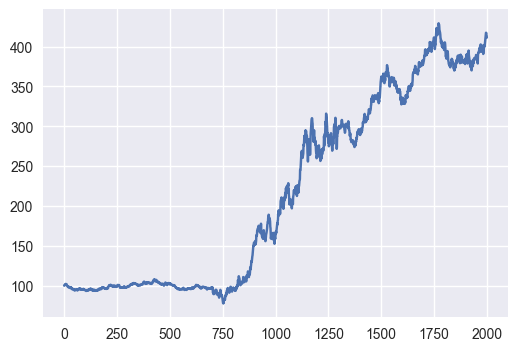

In [2]:
# ============================================================
# GENERATE SYNTHETIC MARKET DATA
# ============================================================

np.random.seed(42)

n = 2000

dates = pd.date_range("2020-01-01", periods=n)

# Simulated volatility regimes
vol_regime = np.concatenate([
    np.ones(700) * 0.005,
    np.ones(600) * 0.02,
    np.ones(700) * 0.008
])

returns = np.random.normal(0, vol_regime)

price = 100 * np.exp(np.cumsum(returns))

df = pd.DataFrame(index=dates)

df["price"] = price
df["returns"] = returns

plt.figure(figsize=(6, 4))
plt.plot(price)
plt.show()

In [3]:
# ============================================================
# CREATE SIMPLE TRADING SIGNALS
# ============================================================

# Momentum
df["mom_5"] = df["price"].pct_change(5)

# Correlated momentum feature
df["mom_10"] = df["price"].pct_change(10)

# Volatility feature
df["vol_20"] = df["returns"].rolling(20).std()

# Mean reversion feature
df["zscore"] = (
    (df["price"] - df["price"].rolling(20).mean())
    / df["price"].rolling(20).std()
)

In [4]:
# ============================================================
# FUTURE RETURNS TARGET
# ============================================================

# Predict next-day returns
df["future_return"] = df["returns"].shift(-1)

df.head()

,price,returns,mom_5,mom_10,vol_20,zscore,future_return
2020-01-01,100.248666,0.002484,NaN,NaN,NaN,NaN,-0.000691
2020-01-02,100.179386,-0.000691,NaN,NaN,NaN,NaN,0.003238
2020-01-03,100.504337,0.003238,NaN,NaN,NaN,NaN,0.007615
2020-01-04,101.272614,0.007615,NaN,NaN,NaN,NaN,-0.001171
2020-01-05,101.154117,-0.001171,NaN,NaN,NaN,NaN,-0.001171


In [5]:
# ============================================================
# LOOKAHEAD BIAS FEATURE (INTENTIONALLY WRONG)
# ============================================================

df["lookahead_feature"] = df["future_return"]

In [6]:
df = df.dropna()
df.shape

(1980, 8)

In [7]:
df.head()

,price,returns,mom_5,mom_10,vol_20,zscore,future_return,lookahead_feature
2020-01-20,98.301603,-0.007062,-0.017747,-0.038762,0.004800,-2.078258,0.007328,0.007328
2020-01-21,99.024627,0.007328,-0.007736,-0.029445,0.005091,-1.350417,-0.001129,-0.001129
2020-01-22,98.912903,-0.001129,-0.003824,-0.028280,0.005092,-1.326441,0.000338,0.000338
2020-01-23,98.946305,0.000338,-0.005052,-0.029127,0.005017,-1.191558,-0.007124,-0.007124
2020-01-24,98.243942,-0.007124,-0.007619,-0.026753,0.004796,-1.505398,-0.002722,-0.002722


# Baseline OLS Regression

$$F = \frac{R^2 / k}{(1 - R^2) / (n - k - 1)}$$

In [8]:
# ============================================================
# BASELINE OLS REGRESSION
# ============================================================

features = ["mom_5", "mom_10", "vol_20", "zscore"]

X = df[features]
y = df["future_return"]

X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          future_return   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2.583
Date:                Tue, 12 May 2026   Prob (F-statistic):             0.0355
Time:                        23:48:06   Log-Likelihood:                 5913.6
No. Observations:                1980   AIC:                        -1.182e+04
Df Residuals:                    1975   BIC:                        -1.179e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.001     -1.167      0.2

High significance predicted for the vol_20 which should not be the case.

# Multicollinearity Test

The variance_inflation_factor function operates by taking one feature at a time (e.g., mom_5) and treating it as the dependent variable. It runs a mini-OLS regression using all the other features (e.g., mom_10, vol_20, zscore) to try and predict that target feature.It then calculates the VIF using the $R^2$ of that mini-regression:
$$VIF_i = \frac{1}{1 - R_i^2}$$
If the other features cannot predict feature $i$ at all, $R_i^2 = 0$, and the VIF is 1. (Perfect independence).If the other features can perfectly predict feature $i$, $R_i^2 = 1$, and the VIF approaches infinity. (Perfect collinearity).

In [9]:
# ============================================================
# MULTICOLLINEARITY
# ============================================================

vif_df = pd.DataFrame()

vif_df["feature"] = X.columns

vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_df

,feature,VIF
0,mom_5,2.383467
1,mom_10,2.766971
2,vol_20,1.073518
3,zscore,2.358179


# Breuch-Pagan Heteroscedasticity Test

In [10]:
# ============================================================
# BREUSCH-PAGAN TEST
# ============================================================

bp_test = het_breuschpagan(model.resid, X_const)

labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

for label, value in zip(labels, bp_test):
    print(f"{label}: {value}")

LM Statistic: 383.45685699464707
LM-Test p-value: 1.043151194793608e-81
F-Statistic: 118.58860436724963
F-Test p-value: 9.287068438552006e-91


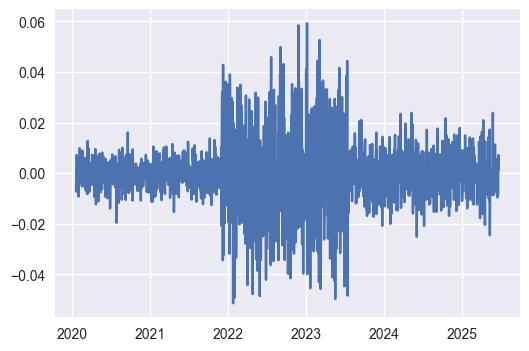

In [11]:
errors = model.predict(X_const) - y

plt.figure(figsize=(6, 4))
plt.plot(errors)
plt.show()

The error is heneroscedastic. Therefore the significance levels are misleading.

# Robust OLS Regression

In [12]:
# ============================================================
# ROBUST STANDARD ERRORS
# ============================================================

robust_model = model.get_robustcov_results(cov_type='HC3')

print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:          future_return   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.570
Date:                Tue, 12 May 2026   Prob (F-statistic):              0.180
Time:                        23:48:06   Log-Likelihood:                 5913.6
No. Observations:                1980   AIC:                        -1.182e+04
Df Residuals:                    1975   BIC:                        -1.179e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.000     -1.358      0.1

The overall F-test now fails, despite the p-value for vol_20 being 0.039.

# Lookahead Bias

In [13]:
# ============================================================
# LOOKAHEAD BIAS DEMONSTRATION
# ============================================================

bad_features = features + ["lookahead_feature"]

X_bad = sm.add_constant(df[bad_features])

bad_model = sm.OLS(y, X_bad).fit()

print(bad_model.summary())

                            OLS Regression Results                            
Dep. Variable:          future_return   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.183e+31
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        23:48:06   Log-Likelihood:                 70823.
No. Observations:                1980   AIC:                        -1.416e+05
Df Residuals:                    1974   BIC:                        -1.416e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              6.326e-17   3.04e-1

The Durbin-Watson Collapse:

In the previous runs, this was hovering near 2.0 (indicating no autocorrelation in the errors). Now it has collapsed near 0, indicating extreme positive autocorrelation. This is because the errors have dropped to zero. Computers cannot calculate absolute zero perfectly in linear algebra; they leave behind microscopic rounding errors (e.g., $10^{-17}$). When the Durbin-Watson formula attempts to calculate the autocorrelation of this infinitesimal floating-point noise, the math breaks down and outputs a meaningless, extreme value.

# Overfitting

In [14]:
# ============================================================
# OVERFITTING DEMO
# ============================================================

# Add random noise features
for i in range(50):
    df[f"noise_{i}"] = np.random.randn(len(df))

noise_features = [f"noise_{i}" for i in range(50)]

all_features = features + noise_features

X_overfit = df[all_features]

split = int(0.7 * len(df))

X_train = X_overfit.iloc[:split]
X_test = X_overfit.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

lr = LinearRegression()

lr.fit(X_train, y_train)

train_pred = lr.predict(X_train)
test_pred = lr.predict(X_test)

print("Train R^2:", r2_score(y_train, train_pred))
print("Test R^2:", r2_score(y_test, test_pred))

Train R^2: 0.03915078727752486
Test R^2: -0.052124953912038086


Ridge regression (also known as L2 Regularization) adds a mathematical penalty for having large coefficients. It changes the objective function that the model is trying to minimize:
$$Loss = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

In [15]:
# ============================================================
# RIDGE REGRESSION
# ============================================================

ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

ridge_train_pred = ridge.predict(X_train)
ridge_test_pred = ridge.predict(X_test)

print("Ridge Train R^2:", r2_score(y_train, ridge_train_pred))
print("Ridge Test R^2:", r2_score(y_test, ridge_test_pred))

Ridge Train R^2: 0.03255728392321
Ridge Test R^2: -0.044346365778144436


# Rolling regression to test for parameter drift

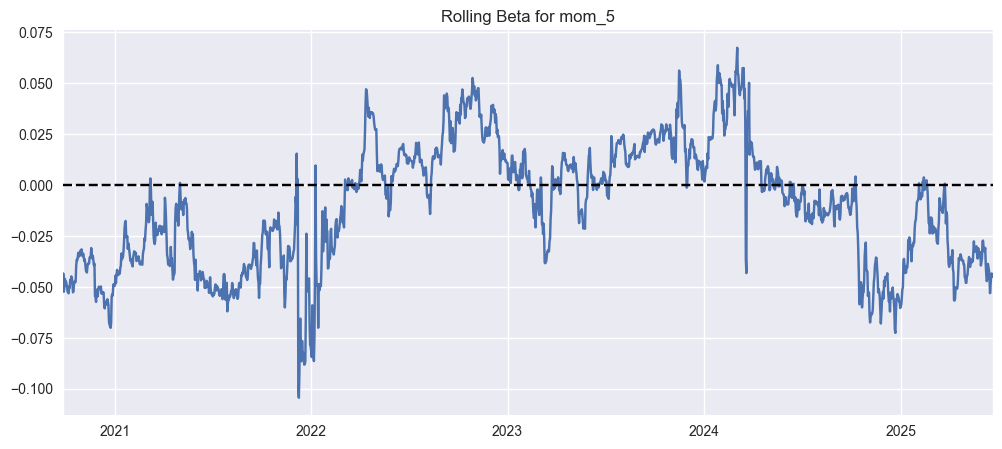

In [16]:
# ============================================================
# ROLLING BETAS
# ============================================================

window = 250

rolling_betas = []

for i in range(window, len(df)):

    temp = df.iloc[i-window:i]

    X_roll = sm.add_constant(temp[features])
    y_roll = temp["future_return"]

    res = sm.OLS(y_roll, X_roll).fit()

    rolling_betas.append(res.params["mom_5"])

rolling_betas = pd.Series(
    rolling_betas,
    index=df.index[window:]
)

plt.figure(figsize=(12, 5))
rolling_betas.plot()
plt.axhline(0, linestyle="--", color="black")
plt.title("Rolling Beta for mom_5")
plt.show()

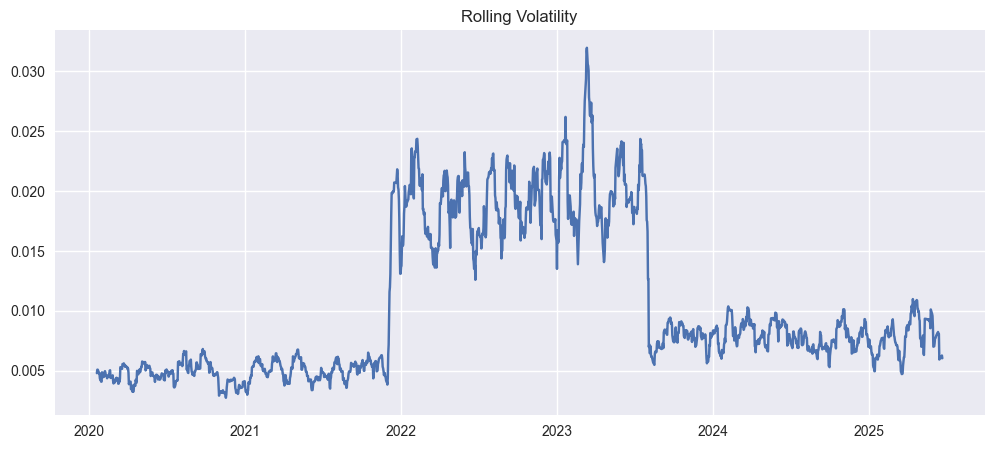

In [17]:
# ============================================================
# REGIME SHIFTS
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["vol_20"])
plt.title("Rolling Volatility")
plt.show()

The feature is completely unstable and highly sensitive to whatever outliers happen to fall into or drop out of the 250-day lookback window. However, there seems to be a correlation with the Beta param with the volatility, where the high-vol regime has a generally positive Beta and the low-vol regimes a generally negative Beta. There is no mechanism that can generative momentum and mean-reverting behaviour in this dataset. This perceived correlation is a pure coincidence.

1. The Random Seed Coincidence
By pure chance, this specific sequence might contain a slight cluster of mean-reverting price action in the first 700 days, and a slight cluster of momentum-like price action in the middle 600 days. This behaviour changes when the random seed is changed.

2. The "Sluggishness" of Rolling Windows
A 250-day rolling window acts as a massive low-pass filter. It contains almost an entire year of data. If a purely random cluster of momentum (consecutive positive or negative days) enters the window, it significantly skews the OLS calculation. Because we only drop one day and add one day at each step, that random cluster stays inside the calculation and drags the beta away from zero for the next 250 steps.

# Signal Validation

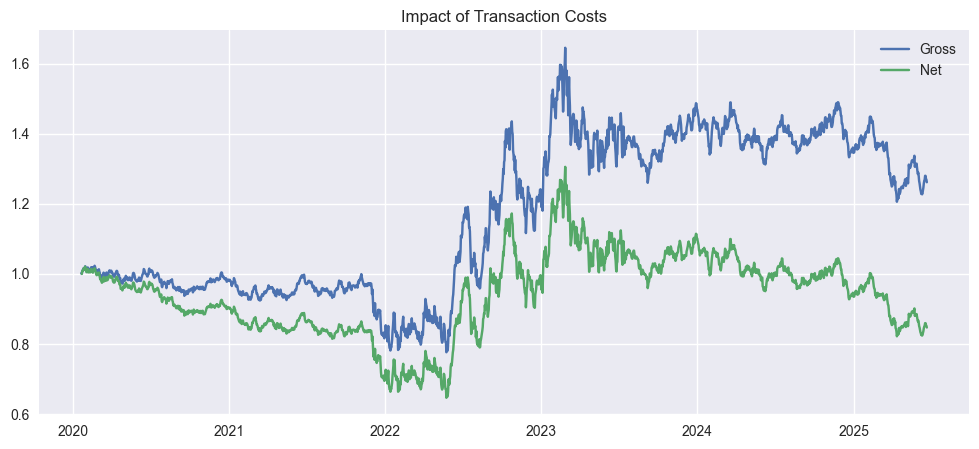

In [18]:
# ============================================================
# SIMPLE BACKTEST
# ============================================================

df["position"] = np.sign(df["mom_5"])

# Shift position to avoid lookahead
df["position"] = df["position"].shift(1)

# Gross PnL
df["gross_pnl"] = (
    df["position"] * df["future_return"]
)

# Transaction costs
cost_per_trade = 0.0005

df["turnover"] = (
    df["position"].diff().abs()
)

df["costs"] = (
    cost_per_trade * df["turnover"]
)

# Net PnL
df["net_pnl"] = (
    df["gross_pnl"] - df["costs"]
)

# Cumulative returns
df["cum_gross"] = (
    1 + df["gross_pnl"]
).cumprod()

df["cum_net"] = (
    1 + df["net_pnl"]
).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(df["cum_gross"], label="Gross")
plt.plot(df["cum_net"], label="Net")
plt.legend()
plt.title("Impact of Transaction Costs")
plt.show()

Because we know the underlying data is a pure random walk (with an expected forward return of exactly zero), any strategy deployed on it has an expected Gross PnL of exactly zero.

The massive run-up we see in the Gross curve between 2022 and 2023 is entirely due to random seed. By pure coincidence, there is a localized cluster of trending data in that window. If we change the seed to 43, that run-up will vanish, and the Gross curve will plunge.

In [19]:
# ============================================================
# TIME SERIES CROSS VALIDATION
# ============================================================

X_cv = df[features]
y_cv = df["future_return"]

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = []

for train_idx, test_idx in tscv.split(X_cv):

    X_train_cv = X_cv.iloc[train_idx]
    X_test_cv = X_cv.iloc[test_idx]

    y_train_cv = y_cv.iloc[train_idx]
    y_test_cv = y_cv.iloc[test_idx]

    model_cv = LinearRegression()

    model_cv.fit(X_train_cv, y_train_cv)

    preds = model_cv.predict(X_test_cv)

    score = r2_score(y_test_cv, preds)

    cv_scores.append(score)

print("CV Scores:", cv_scores)

print("Average CV Score:", np.mean(cv_scores))

CV Scores: [-0.005021009834478729, -0.17502162822023526, -0.000451531041877562, -0.0052115202518217, -0.000590672515441204]
Average CV Score: -0.037259272372770894


# Key Points

1. Multicollinearity
   - mom_5 and mom_10 overlap heavily
   - unstable coefficients

2. Heteroskedasticity
   - volatility changes over time
   - robust standard errors needed

3. Lookahead Bias
   - future information accidentally leaked
   - unrealistic performance

4. Overfitting
   - random noise features fit in-sample noise
   - poor out-of-sample performance

5. Regime Shifts
   - rolling betas unstable
   - relationships drift over time

6. Transaction Costs
   - gross alpha disappears after costs

7. Stability
   - coefficients vary across periods
   - robustness matters more than in-sample fit